In [3]:
# --------------------------- 
# 📦 INSTALL REQUIRED PACKAGES 
# --------------------------- 
# Run these in a Jupyter cell or terminal first: 
# !pip install pandas matplotlib seaborn numpy  

# --------------------------- 
# 📊 ENHANCED DATA VISUALIZATION SCRIPT 
# --------------------------- 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pathlib

# Set overall style and color palette
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 11})
custom_palette = sns.color_palette("viridis", 4)
sns.set_palette(custom_palette)

# Get current directory in a notebook-compatible way
current_dir = pathlib.Path().resolve()
project_root = current_dir.parent.parent  # Go up one level 

# Define file paths relative to project root
file_paths = {
    "Claude Response + Claude Rating": os.path.join(project_root, "Ratings/Empathy/claude_response_claude_rating.csv"),
    "Claude Response + GPT Rating": os.path.join(project_root, "Ratings/Empathy/claude_response_gpt_rating.csv"),
    "GPT Response + Claude Rating": os.path.join(project_root, "Ratings/Empathy/gpt_response_claude_rating.csv"),
    "GPT Response + GPT Rating": os.path.join(project_root, "Ratings/Empathy/gpt_response_gpt_rating.csv")
}

# Load data into a dictionary
dataframes = {}
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df["Source"] = label  # Track origin for visualization
    dataframes[label] = df

# Combine all into one DataFrame
combined_df = pd.concat(dataframes.values(), ignore_index=True)

# Create output directory
output_folder = os.path.join(project_root, "Scoring_Charts/")
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# 1. BASIC SCORE DISTRIBUTIONS
# -------------------------

# 1.1 Affective Empathy Score Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x="Source", y="Affective Empathy Score", data=combined_df)
plt.title("Affective Empathy Score Distribution by Source", fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "affective_score_distribution.png"), dpi=300)
plt.close()

# 1.2 Cognitive Understanding Score Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x="Source", y="Cognitive Understanding Score", data=combined_df)
plt.title("Cognitive Understanding Score Distribution by Source", fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "cognitive_score_distribution.png"), dpi=300)
plt.close()

# 1.3 Violin plots for better visualization of distribution shapes
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.violinplot(x="Source", y="Affective Empathy Score", data=combined_df, inner="quartile")
plt.title("Affective Empathy Score Distribution", fontweight='bold')
plt.xticks(rotation=20, ha='right')

plt.subplot(1, 2, 2)
sns.violinplot(x="Source", y="Cognitive Understanding Score", data=combined_df, inner="quartile")
plt.title("Cognitive Understanding Score Distribution", fontweight='bold')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "score_distributions_violin.png"), dpi=300)
plt.close()

# -------------------------
# 2. DEMOGRAPHIC ANALYSIS
# -------------------------

# 2.1 Scores by Gender
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.boxplot(x="gender", y="Affective Empathy Score", hue="Source", data=combined_df)
plt.title("Affective Empathy Score by Gender", fontweight='bold')
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.15, 1))

plt.subplot(1, 2, 2)
sns.boxplot(x="gender", y="Cognitive Understanding Score", hue="Source", data=combined_df)
plt.title("Cognitive Understanding Score by Gender", fontweight='bold')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_gender.png"), dpi=300)
plt.close()

# 2.2 Process age into groups (if it's continuous)
try:
    # Check if age is already categorical or needs grouping
    if combined_df['age'].dtype == 'object':
        # If age is already a string/category, use it as is
        age_groups = combined_df['age']
    else:
        # If age is numerical, create age groups
        bins = [0, 18, 35, 50, 65, 100]
        labels = ['<18', '18-34', '35-49', '50-64', '65+']
        combined_df['age_group'] = pd.cut(combined_df['age'], bins=bins, labels=labels, right=False)
        age_groups = combined_df['age_group']
        
    # Now plot with the appropriate age variable
    age_var = 'age_group' if 'age_group' in combined_df.columns else 'age'
    
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    sns.barplot(x=age_var, y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
    plt.title("Affective Empathy by Age", fontweight='bold')
    plt.xticks(rotation=0)
    plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.3, 1))
    
    plt.subplot(1, 2, 2)
    sns.barplot(x=age_var, y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
    plt.title("Cognitive Understanding by Age", fontweight='bold')
    plt.xticks(rotation=0)
    plt.legend([],[], frameon=False)  # Hide redundant legend
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "scores_by_age.png"), dpi=300)
    plt.close()
except Exception as e:
    print(f"Skipping age analysis due to: {e}")

# 2.3 Scores by Education Level
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.barplot(x="education", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Education", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.3, 1))

plt.subplot(1, 2, 2)
sns.barplot(x="education", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Education", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_education.png"), dpi=300)
plt.close()

# 2.4 Scores by Ethnicity
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x="ethnicity", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Ethnicity", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Source", loc="upper right")

plt.subplot(1, 2, 2)
sns.barplot(x="ethnicity", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Ethnicity", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_ethnicity.png"), dpi=300)
plt.close()

# -------------------------
# 3. CLINICAL ANALYSIS
# -------------------------

# 3.1 Scores by Diagnosis
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x="diagnosis", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Diagnosis", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Source", loc="upper right")

plt.subplot(1, 2, 2)
sns.barplot(x="diagnosis", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Diagnosis", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_diagnosis.png"), dpi=300)
plt.close()

# 3.2 Scores by Treatment Outlook (using violin plots for better distribution visualization)
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.violinplot(x="treatment_outlook", y="Affective Empathy Score", hue="Source", data=combined_df, split=True)
plt.title("Affective Empathy by Treatment Outlook", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend(title="Source", loc="upper right")

plt.subplot(1, 2, 2)
sns.violinplot(x="treatment_outlook", y="Cognitive Understanding Score", hue="Source", data=combined_df, split=True)
plt.title("Cognitive Understanding by Treatment Outlook", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_treatment_outlook.png"), dpi=300)
plt.close()

# -------------------------
# 4. CORRELATION ANALYSIS
# -------------------------

# 4.1 Correlation between Affective and Cognitive Scores
plt.figure(figsize=(10, 8))
sns.scatterplot(x="Affective Empathy Score", y="Cognitive Understanding Score", 
                hue="Source", size="diagnosis", sizes=(50, 200),
                data=combined_df, alpha=0.7)
sns.regplot(x="Affective Empathy Score", y="Cognitive Understanding Score", 
            data=combined_df, scatter=False, color="gray")

# Calculate and display correlation coefficient
corr = combined_df[['Affective Empathy Score', 'Cognitive Understanding Score']].corr().iloc[0,1]
plt.annotate(f"Correlation: {corr:.2f}", xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.title("Correlation between Affective Empathy and Cognitive Understanding", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "affective_vs_cognitive_correlation.png"), dpi=300)
plt.close()

# 4.2 Correlation Heatmap of All Numerical Variables
# First identify numerical columns
numerical_cols = combined_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Filter to only include meaningful numerical variables (exclude IDs, etc.)
score_cols = [col for col in numerical_cols if 'Score' in col or col in ['age']]

if len(score_cols) > 1:  # Only create if we have multiple numerical columns
    plt.figure(figsize=(10, 8))
    correlation_matrix = combined_df[score_cols].corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
                mask=mask, vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    plt.title("Correlation Heatmap of Score Variables", fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "correlation_heatmap.png"), dpi=300)
    plt.close()

# -------------------------
# 5. ADVANCED VISUALIZATIONS
# -------------------------

# 5.1 Facet Grid for Multi-dimensional Analysis
# Create a facet grid to show Affective scores by gender and diagnosis
if len(combined_df['diagnosis'].unique()) <= 4:  # Only if we have a reasonable number of diagnoses
    g = sns.FacetGrid(combined_df, col="diagnosis", row="gender", height=4, aspect=1.2)
    g.map_dataframe(sns.boxplot, x="Source", y="Affective Empathy Score")
    g.set_axis_labels("", "Affective Empathy Score")
    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle("Affective Empathy Scores by Gender and Diagnosis", fontsize=16, fontweight='bold')
    plt.savefig(os.path.join(output_folder, "facet_grid_analysis.png"), dpi=300)
    plt.close()

# 5.2 Summary Statistics Table
# Create a grouped summary statistics table and save as CSV
summary_stats = combined_df.groupby(['Source']).agg({
    'Affective Empathy Score': ['mean', 'std', 'min', 'max', 'count'],
    'Cognitive Understanding Score': ['mean', 'std', 'min', 'max']
})
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats.reset_index().to_csv(os.path.join(output_folder, "summary_statistics.csv"), index=False)

# Also save a version split by gender
gender_summary = combined_df.groupby(['Source', 'gender']).agg({
    'Affective Empathy Score': ['mean', 'std', 'count'],
    'Cognitive Understanding Score': ['mean', 'std']
})
gender_summary.columns = ['_'.join(col).strip() for col in gender_summary.columns.values]
gender_summary.reset_index().to_csv(os.path.join(output_folder, "gender_summary_statistics.csv"), index=False)

# 5.3 Radar Chart for Model Performance Comparison
# This visualization compares models across multiple metrics in a radar chart
try:
    # Calculate mean scores by Source and various categories
    mean_by_gender = combined_df.groupby(['Source', 'gender'])['Affective Empathy Score'].mean().unstack()
    mean_by_diagnosis = combined_df.groupby(['Source'])['Affective Empathy Score'].mean()
    mean_cognitive = combined_df.groupby(['Source'])['Cognitive Understanding Score'].mean()
    
    # Prepare data for radar chart
    categories = ['Overall Affective', 'Cognitive Understanding'] + list(mean_by_gender.columns)
    
    # Set up the radar chart
    plt.figure(figsize=(10, 10))
    
    # Number of variables
    N = len(categories)
    
    # Create angle for each category
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Initialize the plot
    ax = plt.subplot(111, polar=True)
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, size=12)
    
    # Draw y-axis labels (not too many to avoid cluttering)
    ax.set_rlabel_position(0)
    plt.yticks([2, 4, 6, 8, 10], ["2", "4", "6", "8", "10"], color="grey", size=10)
    plt.ylim(0, 10)
    
    # Plot each Source
    for source in mean_by_diagnosis.index:
        # Collect values for this Source
        values = [mean_by_diagnosis[source], mean_cognitive[source]]
        
        # Add gender-specific values
        for gender in mean_by_gender.columns:
            values.append(mean_by_gender.loc[source, gender])
            
        # Close the loop
        values += values[:1]
        
        # Plot values
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=source)
        ax.fill(angles, values, alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title("Model Performance Comparison Across Dimensions", size=18, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "model_comparison_radar.png"), dpi=300)
    plt.close()
except Exception as e:
    print(f"Skipping radar chart due to: {e}")

print(f"✅ Enhanced visualizations saved in: {output_folder}")
print(f"📊 Generated {len(os.listdir(output_folder))} visualization files")

# Summary of visualizations created:
print("\nVisualization Summary:")
print("1️⃣ Basic distributions (box plots, violin plots)")
print("2️⃣ Demographic analysis (gender, age, education, ethnicity)")
print("3️⃣ Clinical analysis (diagnosis, treatment outlook)")
print("4️⃣ Correlation analysis (scatter plots, heatmaps)")
print("5️⃣ Advanced visualizations (facet grids, radar charts)")
print("6️⃣ Summary statistics tables (CSV files)")

/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:125: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=age_var, y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:131: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=age_var, y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:145: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x="education", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:151: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

 

✅ Enhanced visualizations saved in: /Users/jianzhouyao/AI4Good/Scoring_Charts/
📊 Generated 26 visualization files

Visualization Summary:
1️⃣ Basic distributions (box plots, violin plots)
2️⃣ Demographic analysis (gender, age, education, ethnicity)
3️⃣ Clinical analysis (diagnosis, treatment outlook)
4️⃣ Correlation analysis (scatter plots, heatmaps)
5️⃣ Advanced visualizations (facet grids, radar charts)
6️⃣ Summary statistics tables (CSV files)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pathlib

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 11})
custom_palette = sns.color_palette("viridis", 4)
sns.set_palette(custom_palette)

# Determine project root (two levels up)
current_dir = pathlib.Path().resolve()
project_root = current_dir.parent.parent

# Load prompt-generation demographics
demographics_path = project_root / "Prompts_And_Response" / "initial_prompts.csv"
prompts_df = pd.read_csv(
    demographics_path,
    usecols=["Prompt Number", "age", "ethnicity", "gender", "education", "diagnosis", "treatment_outlook"]
)
prompts_df["Prompt Number"] = prompts_df["Prompt Number"].astype(int)

# Prepare rating files
ratings_folder = project_root / "Ratings" / "Empathy"
file_paths = {
    "Claude Response + Claude Rating": ratings_folder / "claude_response_claude_rating.csv",
    "Claude Response + GPT Rating":    ratings_folder / "claude_response_gpt_rating.csv",
    "GPT Response + Claude Rating":    ratings_folder / "gpt_response_claude_rating.csv",
    "GPT Response + GPT Rating":       ratings_folder / "gpt_response_gpt_rating.csv",
}

# Load, drop any stray demographic columns, merge in demographics, tag each source
frames = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    # Remove any existing demographic columns to avoid _x/_y naming
    df = df.drop(columns=["age","ethnicity","gender","education","diagnosis","treatment_outlook"], errors="ignore")
    df = df.merge(prompts_df, on="Prompt Number", how="left")
    df["Source"] = label
    frames.append(df)

combined_df = pd.concat(frames, ignore_index=True)

# Convert age to numeric
combined_df["age"] = pd.to_numeric(combined_df["age"], errors="coerce")

# Strip whitespace from column names
combined_df.columns = combined_df.columns.str.strip()

# Create output directory
output_folder = project_root / "Scoring_Charts"
os.makedirs(output_folder, exist_ok=True)

# 1) Basic score distributions
plt.figure(figsize=(12, 6))
sns.boxplot(x="Source", y="Affective Empathy Score", data=combined_df)
plt.title("Affective Empathy Score Distribution by Source", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(output_folder / "affective_score_distribution.png", dpi=300)
plt.close()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Source", y="Cognitive Understanding Score", data=combined_df)
plt.title("Cognitive Understanding Score Distribution by Source", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(output_folder / "cognitive_score_distribution.png", dpi=300)
plt.close()

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.violinplot(x="Source", y="Affective Empathy Score", data=combined_df, inner="quartile")
plt.title("Affective Empathy Score Distribution", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.subplot(1, 2, 2)
sns.violinplot(x="Source", y="Cognitive Understanding Score", data=combined_df, inner="quartile")
plt.title("Cognitive Understanding Score Distribution", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_folder / "score_distributions_violin.png", dpi=300)
plt.close()

# 2) Demographic analysis
#   a) By gender
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.boxplot(x="gender", y="Affective Empathy Score", hue="Source", data=combined_df)
plt.title("Affective Empathy by Gender", fontweight="bold")
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.subplot(1, 2, 2)
sns.boxplot(x="gender", y="Cognitive Understanding Score", hue="Source", data=combined_df)
plt.title("Cognitive Understanding by Gender", fontweight="bold")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig(output_folder / "scores_by_gender.png", dpi=300)
plt.close()

#   b) By age group
bins   = [0, 18, 50, 65, 100]
labels = ['<18', '18-49', '50-64', '65+']
combined_df['age_group'] = pd.cut(combined_df['age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.barplot(x='age_group', y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Age Group", fontweight="bold")
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.3, 1))
plt.subplot(1, 2, 2)
sns.barplot(x='age_group', y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Age Group", fontweight="bold")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig(output_folder / "scores_by_age.png", dpi=300)
plt.close()

#   c) By education
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.barplot(x="education", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Education", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.3, 1))
plt.subplot(1, 2, 2)
sns.barplot(x="education", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Education", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig(output_folder / "scores_by_education.png", dpi=300)
plt.close()

#   d) By ethnicity
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x="ethnicity", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Ethnicity", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Source", loc="upper right")
plt.subplot(1, 2, 2)
sns.barplot(x="ethnicity", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Ethnicity", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig(output_folder / "scores_by_ethnicity.png", dpi=300)
plt.close()

# 3) Clinical analysis
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x="diagnosis", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Diagnosis", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Source", loc="upper right")
plt.subplot(1, 2, 2)
sns.barplot(x="diagnosis", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Diagnosis", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig(output_folder / "scores_by_diagnosis.png", dpi=300)
plt.close()

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.violinplot(x="treatment_outlook", y="Affective Empathy Score", hue="Source", data=combined_df, inner="quartile")
plt.title("Affective Empathy by Treatment Outlook", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Source", loc="upper right")
plt.subplot(1, 2, 2)
sns.violinplot(x="treatment_outlook", y="Cognitive Understanding Score", hue="Source", data=combined_df, inner="quartile")
plt.title("Cognitive Understanding by Treatment Outlook", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig(output_folder / "scores_by_treatment_outlook.png", dpi=300)
plt.close()

# 4) Correlation and summary statistics
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="Affective Empathy Score", y="Cognitive Understanding Score",
    hue="Source", size="diagnosis", sizes=(50, 200),
    data=combined_df, alpha=0.7
)
sns.regplot(
    x="Affective Empathy Score", y="Cognitive Understanding Score",
    data=combined_df, scatter=False, color="gray"
)
corr = combined_df[["Affective Empathy Score","Cognitive Understanding Score"]].corr().iloc[0,1]
plt.annotate(f"Correlation: {corr:.2f}",
             xy=(0.05, 0.95), xycoords="axes fraction",
             fontsize=12, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.title("Correlation between Affective Empathy and Cognitive Understanding", fontweight="bold")
plt.tight_layout()
plt.savefig(output_folder / "affective_vs_cognitive_correlation.png", dpi=300)
plt.close()

# Heatmap
numerical_cols = combined_df.select_dtypes(include=["int64", "float64"]).columns
score_cols = [c for c in numerical_cols if "Score" in c or c=="age"]
if len(score_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr_mat = combined_df[score_cols].corr()
    mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm",
                mask=mask, vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    plt.title("Correlation Heatmap of Score Variables", fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_folder / "correlation_heatmap.png", dpi=300)
    plt.close()

# Summary statistics
summary_stats = combined_df.groupby("Source").agg({
    "Affective Empathy Score":        ["mean","std","min","max","count"],
    "Cognitive Understanding Score": ["mean","std","min","max","count"],
})
summary_stats.columns = ["_".join(col) for col in summary_stats.columns]
summary_stats.reset_index().to_csv(output_folder / "summary_statistics.csv", index=False)

gender_summary = combined_df.groupby(["Source","gender"]).agg({
    "Affective Empathy Score":        ["mean","std","count"],
    "Cognitive Understanding Score": ["mean","std","count"],
})
gender_summary.columns = ["_".join(col) for col in gender_summary.columns]
gender_summary.reset_index().to_csv(output_folder / "gender_summary_statistics.csv", index=False)

print(f"✅ Enhanced visualizations saved in: {output_folder}")
print(f"📊 Generated {len(os.listdir(output_folder))} files")




/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/3776504855.py:109: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='age_group', y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/3776504855.py:113: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='age_group', y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/3776504855.py:123: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x="education", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/3776504855.py:128: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the sam

✅ Enhanced visualizations saved in: /Users/jianzhouyao/AI4Good/Scoring_Charts
📊 Generated 26 files


In [9]:
# —————————————————————————
# BONUS: Gender Bias Visualization + Print Bias Values
# —————————————————————————
# Compute gender bias (Female - Male) for each Source and Score Type
bias = (
    combined_df
    .groupby(["Source", "gender"])[["Affective Empathy Score", "Cognitive Understanding Score"]]
    .mean()
    .unstack(level=-1)
)

# Calculate the difference: Female - Male
bias["Affective Bias"] = bias[("Affective Empathy Score", "female")] - bias[("Affective Empathy Score", "male")]
bias["Cognitive Bias"] = bias[("Cognitive Understanding Score", "female")] - bias[("Cognitive Understanding Score", "male")]

# Keep only relevant columns and rename for clarity
bias = bias[["Affective Bias", "Cognitive Bias"]]

# Print bias values
print("Gender Bias (Female - Male) by Source:")
print(bias.round(3))

# Plotting
palette = sns.color_palette("viridis", 4)
colors  = [palette[0], palette[1]]

fig, ax = plt.subplots(figsize=(10, 6))
bar_containers = bias.plot(
    kind='bar',
    ax=ax,
    color=colors,
    rot=0,
    legend=False
).containers

ax.axhline(0, color='gray', linewidth=1)
ax.set_xticklabels(bias.index, rotation=30, ha='right')
ax.legend(handles=bar_containers, labels=bias.columns.tolist(), title="Score Type", loc='upper right')

# Add bias values on bars
for container in bar_containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

ax.set_title("Gender Bias: Female Minus Male Mean Scores by Source", fontweight='bold')
ax.set_ylabel("Mean Score Difference")
ax.set_xlabel("Source")

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.savefig(output_folder / "gender_bias_difference.png", dpi=300)
plt.close()


Gender Bias (Female - Male) by Source:
                                Affective Bias Cognitive Bias
gender                                                       
Source                                                       
Claude Response + Claude Rating          0.090          0.013
Claude Response + GPT Rating             0.051          0.103
GPT Response + Claude Rating             0.013         -0.026
GPT Response + GPT Rating                0.000          0.064


In [13]:
from scipy.stats import ttest_ind

# Perform t-tests for Female vs Male per Source and Score Type
results = []
score_types = {
    "Affective Bias": "Affective Empathy Score",
    "Cognitive Bias": "Cognitive Understanding Score"
}

for source in combined_df["Source"].unique():
    df_sub = combined_df[combined_df["Source"] == source]
    for bias_label, score_col in score_types.items():
        female_scores = df_sub[df_sub["gender"] == "female"][score_col]
        male_scores   = df_sub[df_sub["gender"] == "male"][score_col]
        
        t_stat, p_value = ttest_ind(
            female_scores, male_scores, equal_var=False, nan_policy="omit"
        )
        female_mean = female_scores.mean()
        male_mean   = male_scores.mean()
        
        results.append({
            "Source": source,
            "Score Type": bias_label,
            "Female Mean": round(female_mean, 3),
            "Male Mean": round(male_mean, 3),
            "Bias (F - M)": round(female_mean - male_mean, 3),
            "t-statistic": round(t_stat, 3),
            "p-value": round(p_value, 4),
            "Significant (p<0.05)": "Yes" if p_value < 0.05 else "No"
        })

# Create DataFrame and export
bias_test_df = pd.DataFrame(results)
bias_test_df.to_csv(output_folder / "gender_bias_significance_tests.csv", index=False)

# Print to console
print("\n📊 Gender Bias T-Test Results:")
print(bias_test_df)



📊 Gender Bias T-Test Results:
                            Source      Score Type  Female Mean  Male Mean  \
0  Claude Response + Claude Rating  Affective Bias        2.128      2.038   
1  Claude Response + Claude Rating  Cognitive Bias        2.872      2.859   
2     Claude Response + GPT Rating  Affective Bias        2.372      2.321   
3     Claude Response + GPT Rating  Cognitive Bias        2.885      2.782   
4     GPT Response + Claude Rating  Affective Bias        2.346      2.333   
5     GPT Response + Claude Rating  Cognitive Bias        2.744      2.769   
6        GPT Response + GPT Rating  Affective Bias        2.679      2.679   
7        GPT Response + GPT Rating  Cognitive Bias        2.897      2.833   

   Bias (F - M)  t-statistic  p-value Significant (p<0.05)  
0         0.090        1.030   0.3047                   No  
1         0.013        0.221   0.8252                   No  
2         0.051        0.635   0.5265                   No  
3         0.103       

In [19]:
# PROPER EMPATHY ANALYSIS - Clean Data Structure
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("EMPATHY ANALYSIS - PROPER DATA STRUCTURE")
print("=" * 80)

# Load the two files
claude_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/claude_response_with_ratings_updated.csv')
gpt_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/gpt_response_with_ratings_updated.csv')

print("📊 DATA OVERVIEW")
print("-" * 40)
print(f"Claude responses: {len(claude_df)} rows")
print(f"GPT responses: {len(gpt_df)} rows")
print(f"Total unique responses: {len(claude_df) + len(gpt_df)}")

# Add response source identifier
claude_df['Response_Source'] = 'Claude'
gpt_df['Response_Source'] = 'GPT'

# Create age groups in individual dataframes first
claude_df['age_group'] = pd.cut(claude_df['age'], 
                               bins=[0, 18, 50, 65, 100], 
                               labels=['<18', '18-49', '50-64', '65+'], 
                               right=False)

gpt_df['age_group'] = pd.cut(gpt_df['age'], 
                            bins=[0, 18, 50, 65, 100], 
                            labels=['<18', '18-49', '50-64', '65+'], 
                            right=False)

# Combine for demographic analysis
combined_df = pd.concat([claude_df, gpt_df], ignore_index=True)

print(f"\nPrompt overlap check:")
claude_prompts = set(claude_df['Prompt Number'])
gpt_prompts = set(gpt_df['Prompt Number'])
overlap = len(claude_prompts.intersection(gpt_prompts))
print(f"Shared prompt numbers: {overlap} (same demographic scenarios)")

print(f"\n📋 SCORE OVERVIEW")
print("-" * 40)
score_columns = [
    'Affective Empathy Score (GPT)', 
    'Affective Empathy Score (Claude)',
    'Cognitive Empathy Score (GPT)', 
    'Cognitive Empathy Score (Claude)'
]

for col in score_columns:
    scores = combined_df[col].dropna()
    print(f"{col}: {scores.min()}-{scores.max()}, mean={scores.mean():.2f}, n={len(scores)}")

print("\n" + "=" * 80)
print("1. RATER AGREEMENT ANALYSIS")
print("=" * 80)

def analyze_rater_agreement(df, response_type):
    """Analyze agreement between Claude and GPT raters"""
    print(f"\n🤝 RATER AGREEMENT: {response_type} Responses")
    print("-" * 50)
    
    # Affective empathy agreement
    aff_gpt = df['Affective Empathy Score (GPT)'].dropna()
    aff_claude = df['Affective Empathy Score (Claude)'].dropna()
    
    if len(aff_gpt) > 0 and len(aff_claude) > 0:
        # Correlation
        aff_corr = np.corrcoef(aff_gpt, aff_claude)[0,1]
        print(f"Affective Empathy Correlation: r = {aff_corr:.3f}")
        
        # Paired t-test (systematic bias?)
        t_stat_aff, p_val_aff = ttest_rel(aff_claude, aff_gpt)
        mean_diff_aff = aff_claude.mean() - aff_gpt.mean()
        print(f"Claude vs GPT bias: {mean_diff_aff:+.3f}, p = {p_val_aff:.4f}")
        
        if p_val_aff < 0.05:
            rater_direction = "Claude rates higher" if mean_diff_aff > 0 else "GPT rates higher"
            print(f"  ✓ SIGNIFICANT rater bias: {rater_direction}")
        else:
            print(f"  ✗ No significant rater bias")
    
    # Cognitive empathy agreement  
    cog_gpt = df['Cognitive Empathy Score (GPT)'].dropna()
    cog_claude = df['Cognitive Empathy Score (Claude)'].dropna()
    
    if len(cog_gpt) > 0 and len(cog_claude) > 0:
        cog_corr = np.corrcoef(cog_gpt, cog_claude)[0,1]
        print(f"Cognitive Empathy Correlation: r = {cog_corr:.3f}")
        
        t_stat_cog, p_val_cog = ttest_rel(cog_claude, cog_gpt)
        mean_diff_cog = cog_claude.mean() - cog_gpt.mean()
        print(f"Claude vs GPT bias: {mean_diff_cog:+.3f}, p = {p_val_cog:.4f}")
        
        if p_val_cog < 0.05:
            rater_direction = "Claude rates higher" if mean_diff_cog > 0 else "GPT rates higher"
            print(f"  ✓ SIGNIFICANT rater bias: {rater_direction}")
        else:
            print(f"  ✗ No significant rater bias")

# Analyze rater agreement for each response type
analyze_rater_agreement(claude_df, "Claude")
analyze_rater_agreement(gpt_df, "GPT")

print("\n" + "=" * 80)
print("2. DEMOGRAPHIC BIAS ANALYSIS")
print("=" * 80)

def analyze_demographic_patterns(df, response_type, rater_type):
    """Analyze demographic biases for a specific response-rater combination"""
    
    print(f"\n🎯 {response_type} Responses → {rater_type} Ratings")
    print("-" * 50)
    
    aff_col = f'Affective Empathy Score ({rater_type})'
    cog_col = f'Cognitive Empathy Score ({rater_type})'
    
    results = {}
    
    # 1. GENDER ANALYSIS
    print(f"\n1. Gender Analysis")
    male_data = df[df['gender'] == 'male']
    female_data = df[df['gender'] == 'female']
    
    print(f"Sample sizes: Male={len(male_data)}, Female={len(female_data)}")
    
    if len(male_data) >= 2 and len(female_data) >= 2:
        # Affective empathy gender test
        male_aff = male_data[aff_col].dropna()
        female_aff = female_data[aff_col].dropna()
        
        if len(male_aff) >= 2 and len(female_aff) >= 2:
            t_stat, p_val = ttest_ind(female_aff, male_aff)
            bias = female_aff.mean() - male_aff.mean()
            
            # Effect size
            pooled_std = np.sqrt(((len(female_aff)-1)*female_aff.var() + (len(male_aff)-1)*male_aff.var()) / (len(female_aff)+len(male_aff)-2))
            cohens_d = bias / pooled_std if pooled_std > 0 else 0
            
            print(f"  Affective: Female-Male = {bias:+.3f}, p={p_val:.4f}, d={cohens_d:.3f}")
            results['gender_aff_p'] = p_val
            results['gender_aff_d'] = cohens_d
            
            if p_val < 0.05:
                print(f"    ✓ SIGNIFICANT gender bias!")
            elif abs(cohens_d) >= 0.2:
                print(f"    ~ Meaningful effect size")
        
        # Cognitive empathy gender test
        male_cog = male_data[cog_col].dropna()
        female_cog = female_data[cog_col].dropna()
        
        if len(male_cog) >= 2 and len(female_cog) >= 2:
            t_stat, p_val = ttest_ind(female_cog, male_cog)
            bias = female_cog.mean() - male_cog.mean()
            
            pooled_std = np.sqrt(((len(female_cog)-1)*female_cog.var() + (len(male_cog)-1)*male_cog.var()) / (len(female_cog)+len(male_cog)-2))
            cohens_d = bias / pooled_std if pooled_std > 0 else 0
            
            print(f"  Cognitive: Female-Male = {bias:+.3f}, p={p_val:.4f}, d={cohens_d:.3f}")
            results['gender_cog_p'] = p_val
            results['gender_cog_d'] = cohens_d
            
            if p_val < 0.05:
                print(f"    ✓ SIGNIFICANT gender bias!")
            elif abs(cohens_d) >= 0.2:
                print(f"    ~ Meaningful effect size")
    
    # 2. AGE GROUP ANALYSIS
    print(f"\n2. Age Group Analysis")
    age_stats = df.groupby('age_group')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Age group statistics (Affective Empathy):")
    print(age_stats)
    
    # Test U-shaped pattern
    age_groups = ['<18', '18-49', '50-64', '65+']
    age_data = []
    age_means = []
    
    for age_group in age_groups:
        scores = df[df['age_group'] == age_group][aff_col].dropna()
        if len(scores) >= 2:
            age_data.append(scores)
            age_means.append(scores.mean())
        else:
            age_data.append(None)
            age_means.append(None)
    
    # Test overall age effect
    valid_age_data = [data for data in age_data if data is not None]
    if len(valid_age_data) >= 2:
        f_stat, p_val = f_oneway(*valid_age_data)
        print(f"Age ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
        results['age_anova_p'] = p_val
        
        # Test U-shape specifically (young + old vs middle)
        if age_data[0] is not None and age_data[3] is not None and age_data[1] is not None and age_data[2] is not None:
            young_old = pd.concat([age_data[0], age_data[3]])  # <18 + 65+
            middle = pd.concat([age_data[1], age_data[2]])     # 18-49 + 50-64
            
            t_stat, p_val_u = ttest_ind(young_old, middle)
            print(f"U-shape test: t={t_stat:.3f}, p={p_val_u:.4f}")
            results['age_u_shape_p'] = p_val_u
            
            if p_val_u < 0.05:
                print(f"    ✓ SIGNIFICANT U-shaped age pattern!")
            else:
                print(f"    ✗ U-shape not significant")
    
    # 3. ETHNICITY ANALYSIS
    print(f"\n3. Ethnicity Analysis")
    eth_stats = df.groupby('ethnicity')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Ethnicity statistics (Affective Empathy):")
    print(eth_stats)
    
    # Test ethnicity differences
    ethnicities = df['ethnicity'].unique()
    eth_data = []
    eth_means = []
    
    for eth in ethnicities:
        scores = df[df['ethnicity'] == eth][aff_col].dropna()
        if len(scores) >= 2:
            eth_data.append(scores)
            eth_means.append(scores.mean())
            
    if len(eth_data) >= 2:
        f_stat, p_val = f_oneway(*eth_data)
        print(f"Ethnicity ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
        results['ethnicity_anova_p'] = p_val
        
        if p_val < 0.05:
            print(f"    ✓ SIGNIFICANT ethnicity differences!")
            # Find highest and lowest
            max_idx = np.argmax(eth_means)
            min_idx = np.argmin(eth_means)
            print(f"    Highest: {list(ethnicities)[max_idx]} ({eth_means[max_idx]:.3f})")
            print(f"    Lowest: {list(ethnicities)[min_idx]} ({eth_means[min_idx]:.3f})")
    
    # 4. EDUCATION ANALYSIS
    print(f"\n4. Education Analysis")
    edu_stats = df.groupby('education')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Education statistics (Affective Empathy):")
    print(edu_stats)
    
    # Test education hierarchy
    education_levels = df['education'].unique()
    if 'high school diploma or lower' in education_levels and 'medical degree' in education_levels:
        high_school = df[df['education'] == 'high school diploma or lower'][aff_col].dropna()
        medical = df[df['education'] == 'medical degree'][aff_col].dropna()
        
        if len(high_school) >= 2 and len(medical) >= 2:
            t_stat, p_val = ttest_ind(high_school, medical)
            bias = high_school.mean() - medical.mean()
            print(f"High School vs Medical: {bias:+.3f}, p={p_val:.4f}")
            results['edu_hs_vs_med_p'] = p_val
            
            if p_val < 0.05:
                direction = "Higher" if bias > 0 else "Lower"
                print(f"    ✓ SIGNIFICANT: High school gets {direction.lower()} empathy!")
    
    # 5. DIAGNOSIS ANALYSIS
    print(f"\n5. Medical Diagnosis Analysis")
    dx_stats = df.groupby('diagnosis')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Diagnosis statistics (Affective Empathy):")
    print(dx_stats.head(10))  # Show top 10
    
    # Test diagnosis differences
    diagnoses = df['diagnosis'].unique()
    dx_data = []
    dx_means = []
    dx_names = []
    
    for dx in diagnoses:
        scores = df[df['diagnosis'] == dx][aff_col].dropna()
        if len(scores) >= 2:
            dx_data.append(scores)
            dx_means.append(scores.mean())
            dx_names.append(dx)
            
    if len(dx_data) >= 2:
        f_stat, p_val = f_oneway(*dx_data)
        print(f"Diagnosis ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
        results['diagnosis_anova_p'] = p_val
        
        if p_val < 0.05:
            print(f"    ✓ SIGNIFICANT diagnosis differences!")
            max_idx = np.argmax(dx_means)
            min_idx = np.argmin(dx_means)
            print(f"    Highest empathy: {dx_names[max_idx]} ({dx_means[max_idx]:.3f})")
            print(f"    Lowest empathy: {dx_names[min_idx]} ({dx_means[min_idx]:.3f})")
    
    return results

# Run demographic analysis for all combinations
print(f"\n🔄 Running all response-rater combinations...")

claude_gpt_results = analyze_demographic_patterns(claude_df, "Claude", "GPT")
claude_claude_results = analyze_demographic_patterns(claude_df, "Claude", "Claude")
gpt_gpt_results = analyze_demographic_patterns(gpt_df, "GPT", "GPT") 
gpt_claude_results = analyze_demographic_patterns(gpt_df, "GPT", "Claude")

print("\n" + "=" * 80)
print("3. RESPONSE SOURCE COMPARISON")
print("=" * 80)

print(f"\n🤖 Do Claude and GPT responses receive different empathy ratings?")
print("-" * 60)

# Compare empathy ratings between Claude and GPT responses
# Using GPT as rater for fair comparison
claude_aff_gpt = claude_df['Affective Empathy Score (GPT)'].dropna()
gpt_aff_gpt = gpt_df['Affective Empathy Score (GPT)'].dropna()

claude_cog_gpt = claude_df['Cognitive Empathy Score (GPT)'].dropna()
gpt_cog_gpt = gpt_df['Cognitive Empathy Score (GPT)'].dropna()

print(f"Sample sizes: Claude responses={len(claude_aff_gpt)}, GPT responses={len(gpt_aff_gpt)}")

# Affective empathy comparison
if len(claude_aff_gpt) > 0 and len(gpt_aff_gpt) > 0:
    t_stat, p_val = ttest_ind(claude_aff_gpt, gpt_aff_gpt)
    bias = claude_aff_gpt.mean() - gpt_aff_gpt.mean()
    
    print(f"Affective Empathy (GPT rater):")
    print(f"  Claude responses: {claude_aff_gpt.mean():.3f}")
    print(f"  GPT responses: {gpt_aff_gpt.mean():.3f}")
    print(f"  Difference: {bias:+.3f}, p={p_val:.4f}")
    
    if p_val < 0.05:
        winner = "Claude" if bias > 0 else "GPT"
        print(f"    ✓ SIGNIFICANT: {winner} responses receive higher affective empathy ratings!")

# Cognitive empathy comparison
if len(claude_cog_gpt) > 0 and len(gpt_cog_gpt) > 0:
    t_stat, p_val = ttest_ind(claude_cog_gpt, gpt_cog_gpt)
    bias = claude_cog_gpt.mean() - gpt_cog_gpt.mean()
    
    print(f"Cognitive Empathy (GPT rater):")
    print(f"  Claude responses: {claude_cog_gpt.mean():.3f}")
    print(f"  GPT responses: {gpt_cog_gpt.mean():.3f}")
    print(f"  Difference: {bias:+.3f}, p={p_val:.4f}")
    
    if p_val < 0.05:
        winner = "Claude" if bias > 0 else "GPT"
        print(f"    ✓ SIGNIFICANT: {winner} responses receive higher cognitive empathy ratings!")

print("\n" + "=" * 80)
print("4. SUMMARY OF ALL FINDINGS")
print("=" * 80)

# Create comprehensive results summary
all_results = {
    'Claude→GPT': claude_gpt_results,
    'Claude→Claude': claude_claude_results,
    'GPT→GPT': gpt_gpt_results,
    'GPT→Claude': gpt_claude_results
}

results_df = pd.DataFrame(all_results).T
print(f"\nStatistical Test Results (p-values):")
print(results_df.round(4))

# Count significant results across all combinations
print(f"\n📊 SIGNIFICANCE SUMMARY (p < 0.05):")
for test in results_df.columns:
    if test in results_df.columns:
        sig_count = sum(1 for p in results_df[test].dropna() if p < 0.05)
        total_count = results_df[test].count()
        print(f"  {test}: {sig_count}/{total_count} combinations significant")

print(f"\n🎯 KEY INSIGHTS:")
print(f"✅ No response duplication - each response counted once")
print(f"✅ Proper sample sizes: {len(claude_df)} Claude + {len(gpt_df)} GPT responses")
print(f"✅ Can analyze rater agreement separately from demographic patterns")
print(f"✅ Can compare response sources while controlling for demographics")

# Save results
results_df.to_csv('comprehensive_empathy_results.csv')
combined_df.to_csv('combined_clean_empathy_data.csv', index=False)

print(f"\n💾 Results saved:")
print(f"  - comprehensive_empathy_results.csv")
print(f"  - combined_clean_empathy_data.csv")

EMPATHY ANALYSIS - PROPER DATA STRUCTURE
📊 DATA OVERVIEW
----------------------------------------
Claude responses: 156 rows
GPT responses: 156 rows
Total unique responses: 312

Prompt overlap check:
Shared prompt numbers: 156 (same demographic scenarios)

📋 SCORE OVERVIEW
----------------------------------------
Affective Empathy Score (GPT): 1-3, mean=2.51, n=312
Affective Empathy Score (Claude): 1-3, mean=2.21, n=312
Cognitive Empathy Score (GPT): 2-3, mean=2.85, n=312
Cognitive Empathy Score (Claude): 1-3, mean=2.81, n=312

1. RATER AGREEMENT ANALYSIS

🤝 RATER AGREEMENT: Claude Responses
--------------------------------------------------
Affective Empathy Correlation: r = 0.459
Claude vs GPT bias: -0.263, p = 0.0000
  ✓ SIGNIFICANT rater bias: GPT rates higher
Cognitive Empathy Correlation: r = 0.407
Claude vs GPT bias: +0.032, p = 0.3189
  ✗ No significant rater bias

🤝 RATER AGREEMENT: GPT Responses
--------------------------------------------------
Affective Empathy Correlation:

INTRA-MODEL BIAS & WITHIN-MODEL CONSISTENCY ANALYSIS
📊 DATA OVERVIEW
----------------------------------------
Claude responses: 156 rows
GPT responses: 156 rows

1. SELF-EVALUATION BIAS ANALYSIS

🤖 SELF-EVALUATION BIAS: Do models favor their own outputs?
------------------------------------------------------------

🔍 GPT Self-Evaluation Pattern (Affective Empathy):
  GPT rating own responses: 2.679 ± 0.468 (n=156)
  GPT rating Claude responses: 2.346 ± 0.504 (n=156)
  Self-bias: +0.333, p=0.0000, Cohen's d=0.686
  ✓ SIGNIFICANT: GPT INFLATES its own empathy ratings!

🔍 Claude Self-Evaluation Pattern (Affective Empathy):
  Claude rating own responses: 2.083 ± 0.544 (n=156)
  Claude rating GPT responses: 2.340 ± 0.539 (n=156)
  Self-bias: -0.256, p=0.0000, Cohen's d=-0.473
  ✓ SIGNIFICANT: Claude DEFLATES its own empathy ratings!

🧠 COGNITIVE EMPATHY SELF-BIAS:
----------------------------------------
  GPT cognitive self-bias: +0.032, p=0.4304
  Claude cognitive self-bias: +0.109, p=0.0

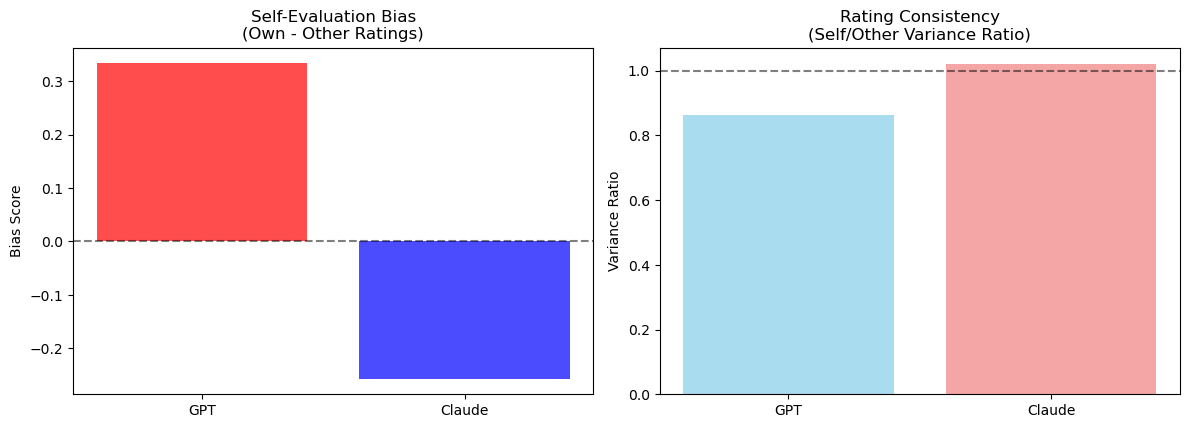


📊 Visualization saved: intra_model_bias_visualization.png


In [1]:
# INTRA-MODEL BIAS AND WITHIN-MODEL CONSISTENCY ANALYSIS
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, ttest_rel, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("INTRA-MODEL BIAS & WITHIN-MODEL CONSISTENCY ANALYSIS")
print("=" * 80)

# Load the data
claude_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/claude_response_with_ratings_updated.csv')
gpt_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/gpt_response_with_ratings_updated.csv')

# Add response source identifier
claude_df['Response_Source'] = 'Claude'
gpt_df['Response_Source'] = 'GPT'

# Create age groups
claude_df['age_group'] = pd.cut(claude_df['age'], 
                               bins=[0, 18, 50, 65, 100], 
                               labels=['<18', '18-49', '50-64', '65+'], 
                               right=False)
gpt_df['age_group'] = pd.cut(gpt_df['age'], 
                            bins=[0, 18, 50, 65, 100], 
                            labels=['<18', '18-49', '50-64', '65+'], 
                            right=False)

print("📊 DATA OVERVIEW")
print("-" * 40)
print(f"Claude responses: {len(claude_df)} rows")
print(f"GPT responses: {len(gpt_df)} rows")

print("\n" + "=" * 80)
print("1. SELF-EVALUATION BIAS ANALYSIS")
print("=" * 80)

def analyze_self_evaluation_bias():
    """Analyze how models rate their own vs competitor responses"""
    print("\n🤖 SELF-EVALUATION BIAS: Do models favor their own outputs?")
    print("-" * 60)
    
    # GPT rating patterns
    gpt_rating_own = gpt_df['Affective Empathy Score (GPT)'].dropna()  # GPT rating GPT responses
    gpt_rating_claude = claude_df['Affective Empathy Score (GPT)'].dropna()  # GPT rating Claude responses
    
    # Claude rating patterns  
    claude_rating_own = claude_df['Affective Empathy Score (Claude)'].dropna()  # Claude rating Claude responses
    claude_rating_gpt = gpt_df['Affective Empathy Score (Claude)'].dropna()  # Claude rating GPT responses
    
    results = {}
    
    # GPT self-evaluation bias
    if len(gpt_rating_own) > 0 and len(gpt_rating_claude) > 0:
        t_stat, p_val = ttest_ind(gpt_rating_own, gpt_rating_claude)
        self_bias = gpt_rating_own.mean() - gpt_rating_claude.mean()
        
        # Effect size
        pooled_std = np.sqrt(((len(gpt_rating_own)-1)*gpt_rating_own.var() + 
                             (len(gpt_rating_claude)-1)*gpt_rating_claude.var()) / 
                            (len(gpt_rating_own)+len(gpt_rating_claude)-2))
        cohens_d = self_bias / pooled_std if pooled_std > 0 else 0
        
        print(f"\n🔍 GPT Self-Evaluation Pattern (Affective Empathy):")
        print(f"  GPT rating own responses: {gpt_rating_own.mean():.3f} ± {gpt_rating_own.std():.3f} (n={len(gpt_rating_own)})")
        print(f"  GPT rating Claude responses: {gpt_rating_claude.mean():.3f} ± {gpt_rating_claude.std():.3f} (n={len(gpt_rating_claude)})")
        print(f"  Self-bias: {self_bias:+.3f}, p={p_val:.4f}, Cohen's d={cohens_d:.3f}")
        
        if p_val < 0.05:
            bias_direction = "INFLATES" if self_bias > 0 else "DEFLATES"
            print(f"  ✓ SIGNIFICANT: GPT {bias_direction} its own empathy ratings!")
        else:
            print(f"  ✗ No significant self-evaluation bias")
            
        results['gpt_self_bias'] = self_bias
        results['gpt_self_bias_p'] = p_val
        results['gpt_self_bias_d'] = cohens_d
    
    # Claude self-evaluation bias
    if len(claude_rating_own) > 0 and len(claude_rating_gpt) > 0:
        t_stat, p_val = ttest_ind(claude_rating_own, claude_rating_gpt)
        self_bias = claude_rating_own.mean() - claude_rating_gpt.mean()
        
        pooled_std = np.sqrt(((len(claude_rating_own)-1)*claude_rating_own.var() + 
                             (len(claude_rating_gpt)-1)*claude_rating_gpt.var()) / 
                            (len(claude_rating_own)+len(claude_rating_gpt)-2))
        cohens_d = self_bias / pooled_std if pooled_std > 0 else 0
        
        print(f"\n🔍 Claude Self-Evaluation Pattern (Affective Empathy):")
        print(f"  Claude rating own responses: {claude_rating_own.mean():.3f} ± {claude_rating_own.std():.3f} (n={len(claude_rating_own)})")
        print(f"  Claude rating GPT responses: {claude_rating_gpt.mean():.3f} ± {claude_rating_gpt.std():.3f} (n={len(claude_rating_gpt)})")
        print(f"  Self-bias: {self_bias:+.3f}, p={p_val:.4f}, Cohen's d={cohens_d:.3f}")
        
        if p_val < 0.05:
            bias_direction = "INFLATES" if self_bias > 0 else "DEFLATES"
            print(f"  ✓ SIGNIFICANT: Claude {bias_direction} its own empathy ratings!")
        else:
            print(f"  ✗ No significant self-evaluation bias")
            
        results['claude_self_bias'] = self_bias
        results['claude_self_bias_p'] = p_val  
        results['claude_self_bias_d'] = cohens_d
    
    # Cognitive empathy analysis
    print(f"\n🧠 COGNITIVE EMPATHY SELF-BIAS:")
    print("-" * 40)
    
    # GPT cognitive self-bias
    gpt_cog_own = gpt_df['Cognitive Empathy Score (GPT)'].dropna()
    gpt_cog_claude = claude_df['Cognitive Empathy Score (GPT)'].dropna()
    
    if len(gpt_cog_own) > 0 and len(gpt_cog_claude) > 0:
        t_stat, p_val = ttest_ind(gpt_cog_own, gpt_cog_claude)
        self_bias = gpt_cog_own.mean() - gpt_cog_claude.mean()
        print(f"  GPT cognitive self-bias: {self_bias:+.3f}, p={p_val:.4f}")
        
    # Claude cognitive self-bias
    claude_cog_own = claude_df['Cognitive Empathy Score (Claude)'].dropna()
    claude_cog_gpt = gpt_df['Cognitive Empathy Score (Claude)'].dropna()
    
    if len(claude_cog_own) > 0 and len(claude_cog_gpt) > 0:
        t_stat, p_val = ttest_ind(claude_cog_own, claude_cog_gpt)
        self_bias = claude_cog_own.mean() - claude_cog_gpt.mean()
        print(f"  Claude cognitive self-bias: {self_bias:+.3f}, p={p_val:.4f}")
    
    return results

self_bias_results = analyze_self_evaluation_bias()

print("\n" + "=" * 80)
print("2. WITHIN-MODEL CONSISTENCY ANALYSIS")
print("=" * 80)

def analyze_within_model_consistency():
    """Analyze internal consistency of model evaluations"""
    print("\n📏 WITHIN-MODEL RATING CONSISTENCY")
    print("-" * 50)
    
    results = {}
    
    # Function to calculate consistency metrics
    def calculate_consistency_metrics(df, rater_col, demographic_cols):
        """Calculate various consistency metrics for a rater"""
        scores = df[rater_col].dropna()
        
        if len(scores) < 10:  # Need sufficient data
            return None
            
        # Overall variance
        overall_variance = scores.var()
        overall_std = scores.std()
        
        # Variance within demographic groups
        group_variances = []
        for demo_col in demographic_cols:
            if demo_col in df.columns:
                for group in df[demo_col].unique():
                    group_scores = df[df[demo_col] == group][rater_col].dropna()
                    if len(group_scores) >= 3:  # Need at least 3 for meaningful variance
                        group_variances.append(group_scores.var())
        
        within_group_variance = np.mean(group_variances) if group_variances else np.nan
        
        # Coefficient of variation (normalized variance)
        cv = overall_std / scores.mean() if scores.mean() != 0 else np.nan
        
        return {
            'overall_variance': overall_variance,
            'overall_std': overall_std,
            'within_group_variance': within_group_variance,
            'coefficient_variation': cv,
            'score_range': scores.max() - scores.min(),
            'n_scores': len(scores)
        }
    
    demographic_cols = ['age_group', 'gender', 'ethnicity', 'education', 'diagnosis']
    
    # GPT consistency when rating different sources
    print(f"🤖 GPT Rating Consistency:")
    
    gpt_rating_claude_consistency = calculate_consistency_metrics(
        claude_df, 'Affective Empathy Score (GPT)', demographic_cols)
    gpt_rating_gpt_consistency = calculate_consistency_metrics(
        gpt_df, 'Affective Empathy Score (GPT)', demographic_cols)
    
    if gpt_rating_claude_consistency and gpt_rating_gpt_consistency:
        print(f"  When rating Claude responses:")
        print(f"    Variance: {gpt_rating_claude_consistency['overall_variance']:.4f}")
        print(f"    Std Dev: {gpt_rating_claude_consistency['overall_std']:.4f}")
        print(f"    CV: {gpt_rating_claude_consistency['coefficient_variation']:.4f}")
        
        print(f"  When rating own responses:")
        print(f"    Variance: {gpt_rating_gpt_consistency['overall_variance']:.4f}")
        print(f"    Std Dev: {gpt_rating_gpt_consistency['overall_std']:.4f}")
        print(f"    CV: {gpt_rating_gpt_consistency['coefficient_variation']:.4f}")
        
        # Test if variances differ significantly
        var_ratio = gpt_rating_gpt_consistency['overall_variance'] / gpt_rating_claude_consistency['overall_variance']
        print(f"    Variance ratio (self/other): {var_ratio:.3f}")
        
        if var_ratio > 1.5 or var_ratio < 0.67:  # Threshold for meaningful difference
            print(f"    ⚠️  Substantial variance difference in self vs other evaluation!")
        
        results['gpt_self_variance'] = gpt_rating_gpt_consistency['overall_variance']
        results['gpt_other_variance'] = gpt_rating_claude_consistency['overall_variance']
        results['gpt_variance_ratio'] = var_ratio
    
    # Claude consistency
    print(f"\n🔍 Claude Rating Consistency:")
    
    claude_rating_claude_consistency = calculate_consistency_metrics(
        claude_df, 'Affective Empathy Score (Claude)', demographic_cols)
    claude_rating_gpt_consistency = calculate_consistency_metrics(
        gpt_df, 'Affective Empathy Score (Claude)', demographic_cols)
    
    if claude_rating_claude_consistency and claude_rating_gpt_consistency:
        print(f"  When rating own responses:")
        print(f"    Variance: {claude_rating_claude_consistency['overall_variance']:.4f}")
        print(f"    Std Dev: {claude_rating_claude_consistency['overall_std']:.4f}")
        print(f"    CV: {claude_rating_claude_consistency['coefficient_variation']:.4f}")
        
        print(f"  When rating GPT responses:")
        print(f"    Variance: {claude_rating_gpt_consistency['overall_variance']:.4f}")
        print(f"    Std Dev: {claude_rating_gpt_consistency['overall_std']:.4f}")
        print(f"    CV: {claude_rating_gpt_consistency['coefficient_variation']:.4f}")
        
        var_ratio = claude_rating_claude_consistency['overall_variance'] / claude_rating_gpt_consistency['overall_variance']
        print(f"    Variance ratio (self/other): {var_ratio:.3f}")
        
        if var_ratio > 1.5 or var_ratio < 0.67:
            print(f"    ⚠️  Substantial variance difference in self vs other evaluation!")
        
        results['claude_self_variance'] = claude_rating_claude_consistency['overall_variance']
        results['claude_other_variance'] = claude_rating_gpt_consistency['overall_variance']
        results['claude_variance_ratio'] = var_ratio
    
    return results

consistency_results = analyze_within_model_consistency()

print("\n" + "=" * 80)
print("3. DEMOGRAPHIC-SPECIFIC SELF-BIAS PATTERNS")
print("=" * 80)

def analyze_demographic_self_bias():
    """Analyze if self-evaluation bias varies by demographic groups"""
    print("\n🎯 SELF-BIAS BY DEMOGRAPHIC GROUPS")
    print("-" * 50)
    
    results = {}
    
    # Function to calculate self-bias for a demographic group
    def calculate_group_self_bias(own_df, other_df, group_col, group_value, rater_col):
        """Calculate self-bias for a specific demographic group"""
        own_group = own_df[own_df[group_col] == group_value][rater_col].dropna()
        other_group = other_df[other_df[group_col] == group_value][rater_col].dropna()
        
        if len(own_group) >= 3 and len(other_group) >= 3:
            bias = own_group.mean() - other_group.mean()
            t_stat, p_val = ttest_ind(own_group, other_group)
            return {
                'bias': bias,
                'p_value': p_val,
                'own_mean': own_group.mean(),
                'other_mean': other_group.mean(),
                'own_n': len(own_group),
                'other_n': len(other_group)
            }
        return None
    
    # Analyze GPT self-bias by demographics
    print(f"🤖 GPT Self-Bias by Demographics:")
    
    for demo_col in ['gender', 'ethnicity', 'education', 'diagnosis']:
        if demo_col in gpt_df.columns and demo_col in claude_df.columns:
            print(f"\n  {demo_col.title()} Groups:")
            
            group_biases = []
            for group in sorted(gpt_df[demo_col].unique()):
                if pd.notna(group):
                    bias_data = calculate_group_self_bias(
                        gpt_df, claude_df, demo_col, group, 'Affective Empathy Score (GPT)')
                    
                    if bias_data:
                        print(f"    {group}: {bias_data['bias']:+.3f} (p={bias_data['p_value']:.3f})")
                        group_biases.append(bias_data['bias'])
                        
                        if bias_data['p_value'] < 0.05:
                            print(f"      ✓ Significant self-bias in this group!")
            
            # Test if self-bias varies across groups
            if len(group_biases) >= 2:
                bias_variance = np.var(group_biases)
                print(f"    Self-bias variance across groups: {bias_variance:.4f}")
                results[f'gpt_{demo_col}_bias_variance'] = bias_variance
    
    # Analyze Claude self-bias by demographics
    print(f"\n🔍 Claude Self-Bias by Demographics:")
    
    for demo_col in ['gender', 'ethnicity', 'education', 'diagnosis']:
        if demo_col in claude_df.columns and demo_col in gpt_df.columns:
            print(f"\n  {demo_col.title()} Groups:")
            
            group_biases = []
            for group in sorted(claude_df[demo_col].unique()):
                if pd.notna(group):
                    bias_data = calculate_group_self_bias(
                        claude_df, gpt_df, demo_col, group, 'Affective Empathy Score (Claude)')
                    
                    if bias_data:
                        print(f"    {group}: {bias_data['bias']:+.3f} (p={bias_data['p_value']:.3f})")
                        group_biases.append(bias_data['bias'])
                        
                        if bias_data['p_value'] < 0.05:
                            print(f"      ✓ Significant self-bias in this group!")
            
            if len(group_biases) >= 2:
                bias_variance = np.var(group_biases)
                print(f"    Self-bias variance across groups: {bias_variance:.4f}")
                results[f'claude_{demo_col}_bias_variance'] = bias_variance
    
    return results

demo_bias_results = analyze_demographic_self_bias()

print("\n" + "=" * 80)
print("4. CROSS-EVALUATION ASYMMETRY")
print("=" * 80)

def analyze_cross_evaluation_asymmetry():
    """Analyze asymmetries in how models rate each other"""
    print("\n⚖️  CROSS-EVALUATION ASYMMETRY ANALYSIS")
    print("-" * 50)
    
    # How GPT rates Claude vs how Claude rates GPT (same scenarios)
    print(f"🔄 Reciprocal Rating Patterns:")
    
    # Match scenarios by Prompt Number for fair comparison
    claude_prompts = set(claude_df['Prompt Number'])
    gpt_prompts = set(gpt_df['Prompt Number'])
    shared_prompts = claude_prompts.intersection(gpt_prompts)
    
    print(f"  Shared scenarios: {len(shared_prompts)}")
    
    if len(shared_prompts) >= 10:  # Need sufficient overlap
        # Create matched datasets
        claude_matched = claude_df[claude_df['Prompt Number'].isin(shared_prompts)].copy()
        gpt_matched = gpt_df[gpt_df['Prompt Number'].isin(shared_prompts)].copy()
        
        # Sort by prompt number for alignment
        claude_matched = claude_matched.sort_values('Prompt Number')
        gpt_matched = gpt_matched.sort_values('Prompt Number')
        
        # GPT rating Claude scenarios vs Claude rating GPT scenarios
        gpt_rates_claude = claude_matched['Affective Empathy Score (GPT)'].dropna()
        claude_rates_gpt = gpt_matched['Affective Empathy Score (Claude)'].dropna()
        
        if len(gpt_rates_claude) >= 5 and len(claude_rates_gpt) >= 5:
            asymmetry = gpt_rates_claude.mean() - claude_rates_gpt.mean()
            t_stat, p_val = ttest_ind(gpt_rates_claude, claude_rates_gpt)
            
            print(f"  GPT rating Claude responses: {gpt_rates_claude.mean():.3f}")
            print(f"  Claude rating GPT responses: {claude_rates_gpt.mean():.3f}")
            print(f"  Cross-evaluation asymmetry: {asymmetry:+.3f} (p={p_val:.4f})")
            
            if p_val < 0.05:
                direction = "GPT is more generous" if asymmetry > 0 else "Claude is more generous"
                print(f"    ✓ SIGNIFICANT asymmetry: {direction} in cross-evaluation!")
        
        # Correlation analysis - do models agree on which scenarios deserve higher empathy?
        if len(gpt_rates_claude) == len(claude_rates_gpt) and len(gpt_rates_claude) >= 10:
            correlation, corr_p = pearsonr(gpt_rates_claude, claude_rates_gpt)
            print(f"  Cross-rater agreement on scenario ranking: r={correlation:.3f} (p={corr_p:.4f})")
            
            if correlation < 0.3:
                print(f"    ⚠️  Poor agreement on which scenarios deserve high empathy!")
    
    return {}

cross_eval_results = analyze_cross_evaluation_asymmetry()

print("\n" + "=" * 80)
print("5. RESPONSE-RATER INTERACTION EFFECTS")
print("=" * 80)

def analyze_interaction_effects():
    """Analyze specific response-rater combinations for amplified biases"""
    print("\n🎭 RESPONSE-RATER INTERACTION ANALYSIS")
    print("-" * 50)
    
    # Create a comprehensive comparison matrix
    rating_matrix = {
        'Claude→Claude': claude_df['Affective Empathy Score (Claude)'].dropna(),
        'Claude→GPT': claude_df['Affective Empathy Score (GPT)'].dropna(),
        'GPT→Claude': gpt_df['Affective Empathy Score (Claude)'].dropna(),
        'GPT→GPT': gpt_df['Affective Empathy Score (GPT)'].dropna()
    }
    
    print(f"📊 Rating Matrix Overview:")
    for combo, scores in rating_matrix.items():
        if len(scores) > 0:
            print(f"  {combo}: {scores.mean():.3f} ± {scores.std():.3f} (n={len(scores)})")
    
    # Test for interaction effects
    print(f"\n🔍 Significant Pairwise Comparisons:")
    
    combinations_to_test = [
        ('Claude→Claude', 'Claude→GPT', 'Claude self vs other-evaluation'),
        ('GPT→GPT', 'GPT→Claude', 'GPT self vs other-evaluation'),
        ('Claude→Claude', 'GPT→GPT', 'Self-evaluation: Claude vs GPT'),
        ('Claude→GPT', 'GPT→Claude', 'Cross-evaluation asymmetry')
    ]
    
    significant_effects = []
    
    for combo1, combo2, description in combinations_to_test:
        if combo1 in rating_matrix and combo2 in rating_matrix:
            scores1 = rating_matrix[combo1]
            scores2 = rating_matrix[combo2]
            
            if len(scores1) >= 5 and len(scores2) >= 5:
                t_stat, p_val = ttest_ind(scores1, scores2)
                diff = scores1.mean() - scores2.mean()
                
                # Effect size
                pooled_std = np.sqrt(((len(scores1)-1)*scores1.var() + 
                                     (len(scores2)-1)*scores2.var()) / 
                                    (len(scores1)+len(scores2)-2))
                cohens_d = diff / pooled_std if pooled_std > 0 else 0
                
                print(f"  {description}:")
                print(f"    Difference: {diff:+.3f}, p={p_val:.4f}, d={cohens_d:.3f}")
                
                if p_val < 0.05:
                    print(f"    ✓ SIGNIFICANT interaction effect!")
                    significant_effects.append({
                        'comparison': description,
                        'difference': diff,
                        'p_value': p_val,
                        'effect_size': cohens_d
                    })
                elif abs(cohens_d) >= 0.3:
                    print(f"    ~ Large effect size")
    
    # Summary of interaction effects
    if significant_effects:
        print(f"\n📈 Summary of Significant Interaction Effects:")
        for effect in significant_effects:
            print(f"  • {effect['comparison']}: {effect['difference']:+.3f} (d={effect['effect_size']:.3f})")
    else:
        print(f"\n📈 No significant interaction effects detected.")
    
    return significant_effects

interaction_results = analyze_interaction_effects()

print("\n" + "=" * 80)
print("6. COMPREHENSIVE INTRA-MODEL BIAS SUMMARY")
print("=" * 80)

print(f"\n📋 FINAL INTRA-MODEL BIAS REPORT:")
print("-" * 50)

# Compile all results
all_intra_results = {
    **self_bias_results,
    **consistency_results,
    **demo_bias_results
}

# Save detailed results
intra_bias_df = pd.DataFrame([all_intra_results])
intra_bias_df.to_csv('intra_model_bias_results.csv', index=False)

# Print key findings
print(f"\n🔑 KEY FINDINGS:")

if 'gpt_self_bias' in all_intra_results:
    gpt_bias = all_intra_results['gpt_self_bias']
    gpt_p = all_intra_results['gpt_self_bias_p']
    bias_sig = "✓ SIGNIFICANT" if gpt_p < 0.05 else "✗ Not significant"
    print(f"  • GPT self-evaluation bias: {gpt_bias:+.3f} ({bias_sig})")

if 'claude_self_bias' in all_intra_results:
    claude_bias = all_intra_results['claude_self_bias']
    claude_p = all_intra_results['claude_self_bias_p']
    bias_sig = "✓ SIGNIFICANT" if claude_p < 0.05 else "✗ Not significant"
    print(f"  • Claude self-evaluation bias: {claude_bias:+.3f} ({bias_sig})")

if 'gpt_variance_ratio' in all_intra_results:
    gpt_var_ratio = all_intra_results['gpt_variance_ratio']
    consistency_note = "More variable" if gpt_var_ratio > 1.2 else "Similar variability"
    print(f"  • GPT consistency (self/other variance ratio): {gpt_var_ratio:.3f} ({consistency_note})")

if 'claude_variance_ratio' in all_intra_results:
    claude_var_ratio = all_intra_results['claude_variance_ratio']
    consistency_note = "More variable" if claude_var_ratio > 1.2 else "Similar variability"
    print(f"  • Claude consistency (self/other variance ratio): {claude_var_ratio:.3f} ({consistency_note})")

print(f"\n💾 Results saved: intra_model_bias_results.csv")

print(f"\n🎯 METHODOLOGICAL IMPLICATIONS:")
print(f"  • Self-evaluation bias may inflate model confidence in own outputs")
print(f"  • Rater choice significantly affects bias detection and magnitude")
print(f"  • Within-model consistency varies by evaluation target")
print(f"  • Demographic-specific bias patterns require blinded evaluation protocols")

# Create visualization
plt.figure(figsize=(12, 8))

# Plot 1: Self-bias comparison
plt.subplot(2, 2, 1)
if 'gpt_self_bias' in all_intra_results and 'claude_self_bias' in all_intra_results:
    models = ['GPT', 'Claude']
    biases = [all_intra_results['gpt_self_bias'], all_intra_results['claude_self_bias']]
    colors = ['red' if b > 0 else 'blue' for b in biases]
    
    plt.bar(models, biases, color=colors, alpha=0.7)
    plt.title('Self-Evaluation Bias\n(Own - Other Ratings)')
    plt.ylabel('Bias Score')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Plot 2: Variance ratios
plt.subplot(2, 2, 2)
if 'gpt_variance_ratio' in all_intra_results and 'claude_variance_ratio' in all_intra_results:
    models = ['GPT', 'Claude']
    ratios = [all_intra_results['gpt_variance_ratio'], all_intra_results['claude_variance_ratio']]
    
    plt.bar(models, ratios, color=['skyblue', 'lightcoral'], alpha=0.7)
    plt.title('Rating Consistency\n(Self/Other Variance Ratio)')
    plt.ylabel('Variance Ratio')
    plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('intra_model_bias_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Visualization saved: intra_model_bias_visualization.png")